<a href="https://colab.research.google.com/github/Elpog1/EMSC2010-A3/blob/main/EMSC2010_A3_u8222275.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Montreal Protocol: Can We Detect Ozone Recovery?**

---


## Problem / Motivation

Chlorofluorocarbons (CFCs), once widely used in aerosols and
refrigerants, destroy stratospheric ozone through catalytic
chain reactions — a single chlorine atom can destroy ~100,000
ozone molecules. The resulting Antarctic ozone hole, first
observed in the 1980s, exposes ecosystems and humans to
increased ultraviolet (UV) radiation, raising skin cancer risk and damaging food chains.

The Montreal Protocol (1987) and its subsequent ammendments banned CFC production globally, but whether a statistically credible recovery is detectable in real atmospheric data remains an open question as recovery is slow, noisy, and easily obscured by natural variability such as volcanism.

**Ammendments to the Montreal Protocol:**

London 1990
*   Added CFCs to the list of strictly controlled substances
*   Mandated a complete global elimination of CFCs, halons, and carbon tetrachloride by 2000 for developed countries
*   Established the Multilateral Fund for the Implementation of the Montreal Protocol, providing technical and financial assistance to help developing nations meet phase-out obligations

Copenhagen 1992
*   Added HCFCs (substitutes for CFCs) and HBFCs to the list of strictly controlled substances
*   Accelerated the target-date for the complete global elimination of CFCs, halons, and carbon tetrachloride to 1st January, 1996 for developed countries

Vienna 1995
*   Added Methyl Bromide to the to the list of strictly controlled substances
*   Stricter controls on the production and consumption of HCFCs

Montreal 1997
*   Introduced a phase-out schedule for HCFCs in developing countries  
*   Set the deadline for phaseout of methyl bromide to be 2005 for developed countries, and 2015 for developing countries
*   Implemented a global licensing system for the control of importing and exporting the controlled ozone-depleting substances

Beijing 1999
*   Added BCM to the list of controlled ozone-depleting substances and established its phase-out date
*   Placed a global cap on the production of HCFCs

Kigali 2016
*   Global agreement to reduce the production and consumption of HFCs

## Research Question

Can we detect the signature of CFC regulation in real atmospheric measurements, and quantify the statistical certainty of the observed ozone hole recovery?

## Hypothesis
Following the Montreal Protocol (1987) and subsequent
CFC bans, atmospheric CFC concentrations declined, leading to
statistically credible reduction in Antarctic ozone hole area after approximately 2007.



---


# Section 1: Fermi Estimation (W2_P2_NB2)

### Problem: How many ozone molecules were destroyed by the total CFC-12 output before the CFC-12 ban?

This Fermi estimation is used to motivate the research question by revealing the extent of the threat that CFCs pose to atmospheric reduction.

CFC-12 releases Cl into the atmosphere, which is what breaks down ozone. By calculating how many ozone molecules are destroyed by one Cl atom, we can hence discover the amount of ozone molecules detroyed by one CFC-12 molecule.

Therefore, using these calculations, we can estimate the total amount of ozone molecules destroyed by the total amount of CFC-12 produced in this time period.

Fermi estimation data sources:
*   NOAA. (2018). What are the chlorine and bromine reactions that destroy stratospheric ozone? https://csl.noaa.gov/assessments/ozone/2018/downloads/twentyquestions/Q8.pdf
*   NOAA. (2002). Twenty Questions. https://csl.noaa.gov/assessments/ozone/2002/qandas9.pdf

In [1]:
# Step 1: From one CFC-12 molecule to ozone destruction

cl_per_cfc12 = 2 # CFC-12 contains 2 chlorine atoms per molecule
catalytic_cycles = 100000 # each Cl atom destroys ~100,000 ozone molecules
ozone_per_cfc12 = cl_per_cfc12 * catalytic_cycles
print(f"Ozone molecules destroyed per CFC-12 molecule: {ozone_per_cfc12:,}")

Ozone molecules destroyed per CFC-12 molecule: 200,000


In [27]:
# Step 2: Scaling up to one aerosol can

mass_can_g = 250                          # typical pre-ban aerosol held ~250g of CFC-12 propellant
molar_mass_cfc12 = 120.9                  # g/mol for CCl2F2
avogadro = 6.022e23                       # molecules per mol

moles_per_can = mass_can_g / molar_mass_cfc12
molecules_per_can = moles_per_can * avogadro
ozone_destroyed_per_can = molecules_per_can * ozone_per_cfc12

print(f"Moles of CFC-12 per aerosol can: {moles_per_can:.2f} mol")
print(f"CFC-12 molecules per aerosol can: {molecules_per_can:.3e}")
print(f"Ozone molecules destroyed per aerosol can: {ozone_destroyed_per_can:.3e}")

Moles of CFC-12 per aerosol can: 2.07 mol
CFC-12 molecules per aerosol can: 1.245e+24
Ozone molecules destroyed per aerosol can: 2.490e+29


In [3]:
# Step 3: Global scale - total CFC-12 production vs total ozone

#How many ozone molecules are there in total?
total_ozone_kg = 3e12                     # Total stratospheric ozone ~ 3e12 kg (3 billion tonnes)
total_ozone_g  = total_ozone_kg * 1000    # convert to grams
molar_mass_o3  = 48                       # Ozone molar mass = 48 g/mol
total_ozone_molecules = (total_ozone_g / molar_mass_o3) * avogadro

# Global CFC-12 production estimate
total_cfc12_production_tonnes = 15e6            # Total production 1930-2000 estimated ~ 15 million tonnes
total_cfc12_production_g = total_cfc12_production_tonnes * 1e6  # convert to grams
total_cfc12_molecules = (total_cfc12_production_g / molar_mass_cfc12) * avogadro

#Final value for total ozone molecules destroyed by CFC-12
total_ozone_destroyed = total_cfc12_molecules * ozone_per_cfc12

#Final value for fraction of the Earth's ozone destroyed
fraction_global = (total_ozone_destroyed / total_ozone_molecules)

print(f"Total stratospheric ozone molecules:          {total_ozone_molecules:.3e}")
print(f"Total CFC-12 molecules ever produced:         {total_cfc12_molecules:.3e}")
print(f"Total ozone molecules potentially destroyed:  {total_ozone_destroyed:.3e}")
print(f"Ratio (destroyed / total ozone):              {fraction_global:.2f}x")

Total stratospheric ozone molecules:          3.764e+37
Total CFC-12 molecules ever produced:         7.471e+34
Total ozone molecules potentially destroyed:  1.494e+40
Ratio (destroyed / total ozone):              397.02x


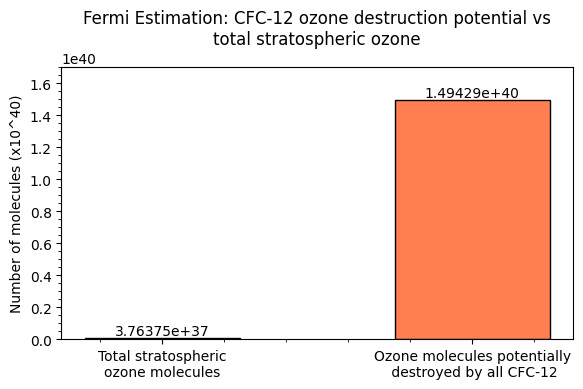

In [4]:
#Fermi visualisation for context
import matplotlib.pyplot as plt #plotting library

fig, ax = plt.subplots(figsize=(6, 4))

labels   = ['Total stratospheric\nozone molecules', 'Ozone molecules potentially\n destroyed by all CFC-12']
values   = [total_ozone_molecules, total_ozone_destroyed]

bars = ax.bar(labels, values, color=['steelblue', 'coral'], edgecolor='black', width=0.5)
ax.bar_label(bars) # Add value labels on top of bars

ax.set_ylabel('Number of molecules (x10^40)')
ax.set_title('Fermi Estimation: CFC-12 ozone destruction potential vs\ntotal stratospheric ozone')
ax.set_ylim(0, 1.7e+40)
ax.minorticks_on()
plt.tight_layout()
plt.show()

The estimated number of ozone molecules in the stratosphere is approximately **3.76 x 10^38**, and the total CFC-12 ever produced **(1.49 x 10^40)** could theoretically destroy approximately **397x** this amount.

### Interpretation of the Fermi Estimation Results:

The Fermi calculation reveals why CFCs posed such a threat despite present in only tiny quantities (parts per trillion). Each CFC-12 molecule releases two chlorine atoms upon UV photolysis in the stratosphere, and each chlorine atom can destroy approximately 100,000 ozone molecules through catalytic cycling before deactivating.

The total CFC-12 ever manufactured could theoretically destroy the entire ozone layer approximately 397 times over. However in reality this did not occur for two reasons:

*   ozone constantly replenishes itself and;
*   not all released CFCs reach the stratosphere before being broken down

### Limitations of the Fermi Estimation:

*   It was **assumed that the ozone hole did not exist before** this event. In reality, there aren't measurements prior to CFC production to suggest that the ozone layer was intact, and in fact it was likely that it wasn't due to natural ozone depletion processes (i.e. volcanic outgassing, solar flares, etc.). This means the estimate overstates the destruction potential relative to the baseline.
*   Some **parameters** such as the catalytic cycle estimate **are simplified** to whole numbers, and also don't take into account stratospheric temperature, pressure, and wind changes which could change the number for of ozone molecules detroyed by one CFC-12 molecule in this estimation.

---


# Section 2: Data Import

Three datasets were used in this project, each sourced from the following scientific institutions:

**Ozone Hole data**: NASA Ozone Watch. (2025). Annual Records. https://ozonewatch.gsfc.nasa.gov/statistics/annual_data.html

**CFC data**: NOAA. Annual Mean Mole Fraction. https://gml.noaa.gov/aggi/NOAA_Annual_Mean_MoleFractions.csv

**Ozone Policy timeline:**
*   UNEP. Ozone timeline. https://ozone.unep.org/ozone-timeline
*   DCCEEW. (2025). Montreal Protocol on Substances that Deplete the Ozone Layer. https://www.dcceew.gov.au/environment/protection/ozone/montreal-protocol


### Data assumptions and limitations:
*   Ozone hole measurements prior to 1992 used a different satellite instrument, introducing systematic uncertainty
*   There is no data available for 1995 in the ozone hole dataset. I have chosen to leave this as a gap rather than interpolating the value.
*   The CFC concetration data are smoothed annual global means from multiple stations. This smoothing has consequences for the lag analysis in Section 5, discussed there.
*   The Dobsun Unit (DU) used for the minimum ozone hole area data, and measures the total column amount of ozone above a point, therefore may measure data differently to the maximum ozone hole area data, measured in million km². Therefore, I have chosen to only use the maximum data past initial visualistation.

Import the libraries/packages we need into the memory.

In [5]:
!pip install bambi #system command to install bambi package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.8/237.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: pytensor
    Found existing installation: pytensor 2.38.3
    Uninstalling pytensor-2.38.3:
      Successfully uninstalled pytensor-2.38.3
  Attempting uninstall: arviz
    Found existing installation: arviz 0.22.0
    Uninstalling arviz-0.22.0:
      Successfully uninstalled arviz-0.22.0
  Attempting uninstall: pymc
    Found existing insta

In [6]:
import numpy as np # NumPy for numerical computing
import bambi as bmb #for automated Bayesian regression
from scipy.stats import norm #Scipy funtion for working with normal distributions
import arviz as az #for analysis of Bayesian models
import pandas as pd #used to read and clean data, bambi requires us to work with pandas dataframes

Next, import and read the excel file:

In [7]:
df_ozone = pd.read_excel('A3_Ozone_Data.xlsx', sheet_name='Ozone_Hole') #read the data into a dataframe
df_ozone.head() # print the table

#NOTE: There is no data available for 1995
#NOTE: The Dobson Unit (DU) is a measure of total ozone

,Year,Max_Area_Sept_Oct (million km^2),Min_Dobson_Sept_Oct
0,1979,0.1,225.0
1,1980,1.4,203.0
2,1981,0.6,209.5
3,1982,4.8,185.0
4,1983,7.9,172.9


In [8]:
df_cfc = pd.read_excel('A3_Ozone_Data.xlsx', sheet_name='CFC_Combined') #read the data into a dataframe
df_cfc.head() # print the table

,Year,CFC11_ppt,CFC12_ppt
0,1979.5,159.0,286.4
1,1980.5,167.9,301.8
2,1981.5,175.9,319.2
3,1982.5,184.0,335.3
4,1983.5,193.0,352.6


In [9]:
df_events = pd.read_excel('A3_Ozone_Data.xlsx', sheet_name='Policy_Events') #read the data into a dataframe
df_events.head(11)

,Year,Event
0,1985,Antarctic ozone hole discovery
1,1987,Montreal Protocol
2,1990,London Amendment — CFC phase-out begins
3,1991,Mount Pinatubo Eruption
4,1992,Copenhagen Amendment
5,1995,Vienna Ammendment
6,1997,Montreal Ammendment
7,2002,Beijing Ammendment
8,2010,CFC production ban globally
9,2016,Kigali Ammendment


Convert the data into numpy arrays to be used for data analysis:

In [10]:
#Ozone Hole data
year_ozone = df_ozone['Year'].to_numpy()
ozone_area = df_ozone['Max_Area_Sept_Oct (million km^2)'].to_numpy()
ozone_dobson = df_ozone['Min_Dobson_Sept_Oct'].to_numpy()

#CFC data
year_cfc  = df_cfc['Year'].to_numpy()
cfc11_ppt = df_cfc['CFC11_ppt'].to_numpy()
cfc12_ppt = df_cfc['CFC12_ppt'].to_numpy()

#Combine the CFC data into one variable to be used for correlation analysis later on
cfc_total = cfc11_ppt + cfc12_ppt

---

# Section 3: Initial Data Visualisation for Context (W3_P1_NB1)
Initial visualisation is necessary before statistical analysis. It allows us to identify long-term trends, anomalies (e.g. the 1991 Pinatubo volcanic eruption), and data quality issues that must be acknowledged before fitting models.

Following the approach from week 3 practical 1, I plotted each variable as a time series with policy event markers. The following three figures were produced:

*   **Figure 1** - ozone hole area and Dobson Units over time, to show the full record and reveal anomalies
*   **Figure 2** - CFC-11 and CFC-12 atmospheric concentrations over time, to reveal the CFC burden and its response to regulation
*   **Figure 3** - CFC total and ozone hole area on a dual axis, to visually establish whether the two series track each other

The Montreal Protocol (1987) and the Mount Pinatubo erruption (1991-1994) are highlighted in these Figures as the most scientifically significant events in the record.

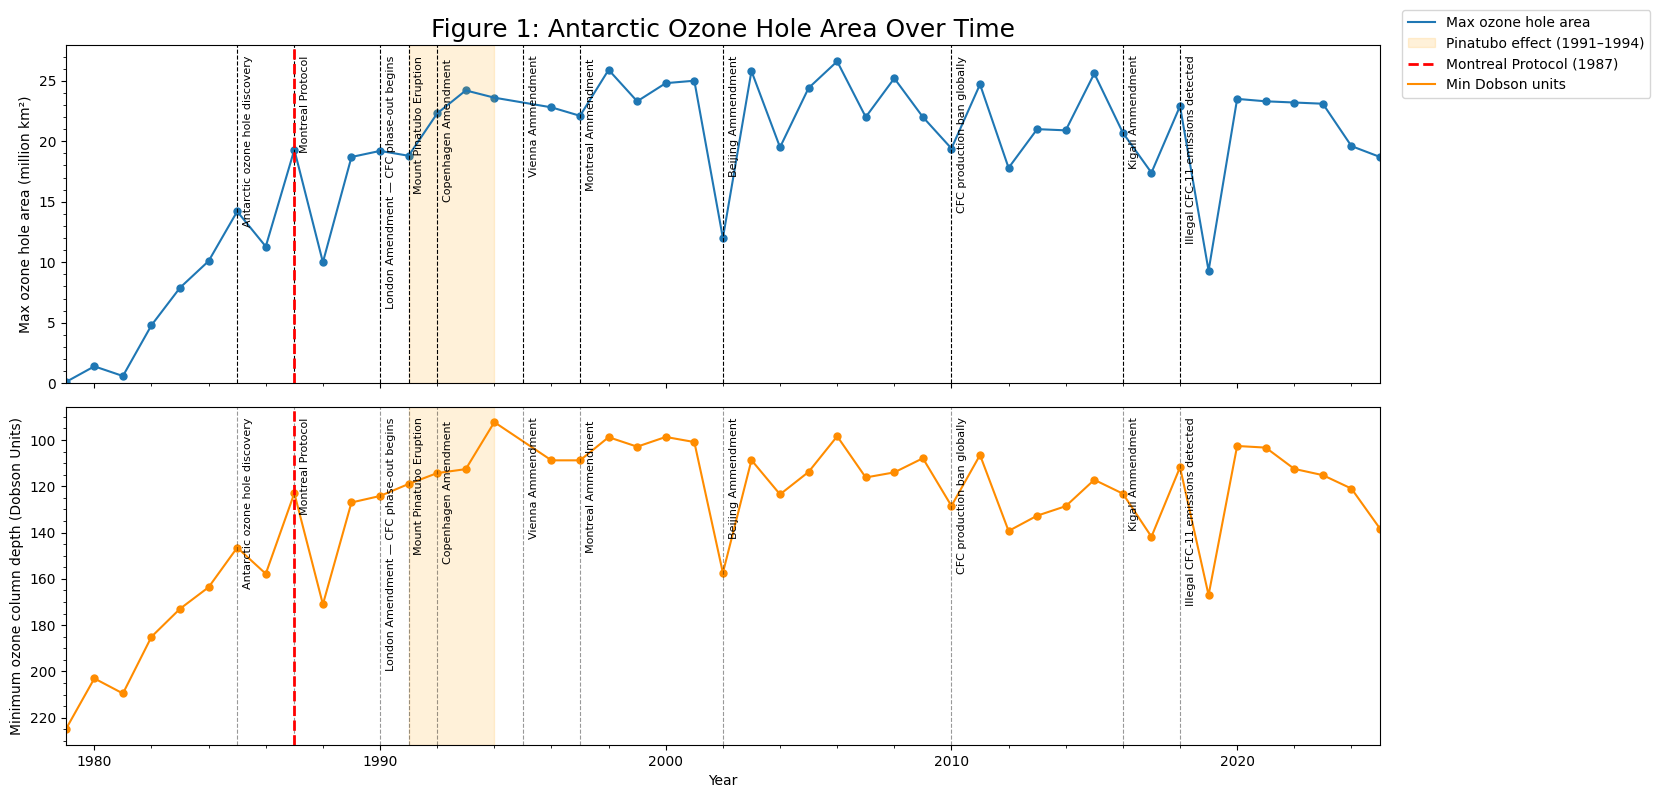

In [11]:
#CODE FROM W3-P1-NB1
# Plot Ozone Hole Area data
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(year_ozone, ozone_area, label='Max ozone hole area')
ax[0].scatter(year_ozone, ozone_area, s=25)  # dots on each data point
ax[0].set_ylabel('Max ozone hole area (million km²)')
ax[0].set_title('Figure 1: Antarctic Ozone Hole Area Over Time', fontsize=18)
ax[0].set_ylim(bottom=0)
ax[0].minorticks_on()

ax[1].plot(year_ozone, ozone_dobson, color='darkorange', label='Min Dobson units')
ax[1].scatter(year_ozone, ozone_dobson, color='darkorange', s=25)
ax[1].invert_yaxis() #Inverted to match the graph above as lower DU means more ozone destruction
ax[1].set_ylabel('Minimum ozone column depth (Dobson Units)')
ax[1].minorticks_on()

ax[1].set_xlabel('Year')
ax[1].set_xlim(1979, 2025)

# Add policy event lines from the dataframe
for _, row in df_events.iterrows():
    ax[0].axvline(x=row['Year'], color='black', linewidth=0.8, linestyle='--')
    ax[0].text(x=row['Year'] + 0.2,        # nudge text slightly right of line
            y=ax[0].get_ylim()[1] * 0.97,  # place text near top of plot
            s=row['Event'],             # the text label from your Excel sheet
            rotation=90,               # rotate vertically
            fontsize=8,
            color='black',
            va='top')

for _, row in df_events.iterrows():
    ax[1].axvline(x=row['Year'], color='black', linewidth=0.8, alpha=0.4, linestyle='--')
    ax[1].text(x=row['Year'] + 0.2,
            y=ax[1].get_ylim()[1] / 0.95,  # divided as the ax[1] data has been inverted
            s=row['Event'],
            rotation=90,
            fontsize=8,
            color='black',
            va='top')

#Highlight the Montreal Protocol and the Pinatubo erruption:
# Pinatubo — orange shading over affected years
ax[0].axvspan(1991, 1994, color='orange', alpha=0.15, label='Pinatubo effect (1991–1994)')
ax[1].axvspan(1991, 1994, color='orange', alpha=0.15)

# Montreal Protocol — thick red line, stands out from other events
ax[0].axvline(x=1987, color='red', linewidth=2, linestyle='--', label='Montreal Protocol (1987)')
ax[1].axvline(x=1987, color='red', linewidth=2, linestyle='--')

fig.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### Figure 1 interpretation

*   A clear rising trend in ozone hole area from 1979 to approximately 2007, consistent with accumulating CFC concentrations in the stratosphere
*   The orange shading indicates the Pinatubo effect following the 1991 Pinatubo eruption, ejected sulphate aerosols into the stratosphere, which provided additional surfaces for ozone-destroying reactions and caused a visible spike in ozone hole area around 1992 - 1993. This demonstrates that natural volcanic events can temporarily overwhelm or mask the policy signal, which is relevant as to why detecting a statistically credible recovery is difficult.
*   The Dobson Units panel mirrors the maximum ozone area panel - when the hole is largest in area, the minimum Dobson value is also lowest, confirming internal consistency between the two measurements.
*   A noisy but visible slight decline is apparent after 2007, which the subsequent analysis will quanitfy

The year-to-year variability (noise) is large - approximately ±5 million km² - driven by natural variation in the strength of the Antarctic polar vortex. This noise is why visual interpretation alone is insufficient to confirm recovery.

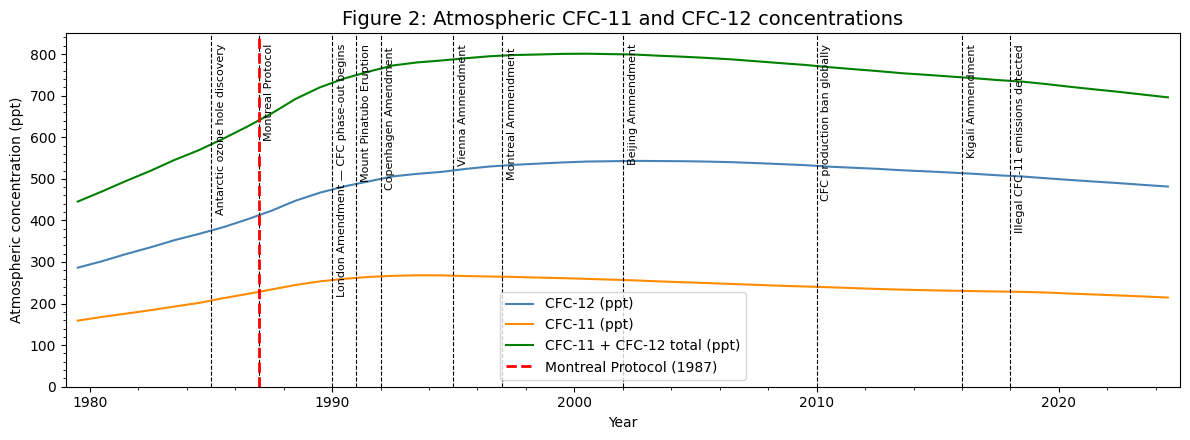

In [12]:
#CODE FROM W3-P1-NB1
#Plot CFC concentrations over time

fig, ax = plt.subplots(figsize=(12, 4.5))

ax.plot(year_cfc, cfc12_ppt, color='steelblue', linewidth=1.5, label='CFC-12 (ppt)')
ax.plot(year_cfc, cfc11_ppt, color='darkorange', linewidth=1.5, label='CFC-11 (ppt)')

#Plot total CFC concentration
ax.plot(year_cfc, cfc_total, color='green', linewidth=1.5, label='CFC-11 + CFC-12 total (ppt)')

# Add policy event lines from the dataframe
for _, row in df_events.iterrows():
    ax.axvline(x=row['Year'], color='black', linewidth=0.8, linestyle='--')
    ax.text(x=row['Year'] + 0.2,        # nudge text slightly right of line
            y=ax.get_ylim()[1] * 0.99,  # place text near top of plot
            s=row['Event'],             # the text label from your Excel sheet
            rotation=90,               # rotate vertically
            fontsize=8,
            color='black',
            va='top')

# Montreal Protocol — thick red line, stands out from other events
ax.axvline(x=1987, color='red', linewidth=2, linestyle='--', label='Montreal Protocol (1987)')

ax.set_xlabel('Year')
ax.set_ylabel('Atmospheric concentration (ppt)')
ax.set_title('Figure 2: Atmospheric CFC-11 and CFC-12 concentrations', fontsize=14)
ax.set_xlim(1979, 2025)
ax.set_ylim(0, 850)
ax.legend()
ax.minorticks_on()
plt.tight_layout()
plt.show()

### Figure 2 Interpretation

*   CFC-12 concentration is consistently higher than CFC-11, reflecting its greater historical production volume
*   Both compounds rise steeply from the late 1970s, plateau around 1992-1994, and then decline - the plateau and decline align closely with the Montreal protocol and its ammendments accelerating the phase-out schedule
*   CFC-11 shows a visible flattening in its declining rate around 2012-2019. This is the signature of illegal CFC-11 manufacturing detected in 2018-2019, later traced to industrial production in eastern China. This event is a genuine threat to the recovey timeline and is discussed further in Section 6
*   The CFC data are smooth curves with little noise because they are global annual mean concentrations averaged across multiple monitorin stations. This smoothness has consequences for the lag analysis in Section 5

**Combine these inital plots for comparison:**

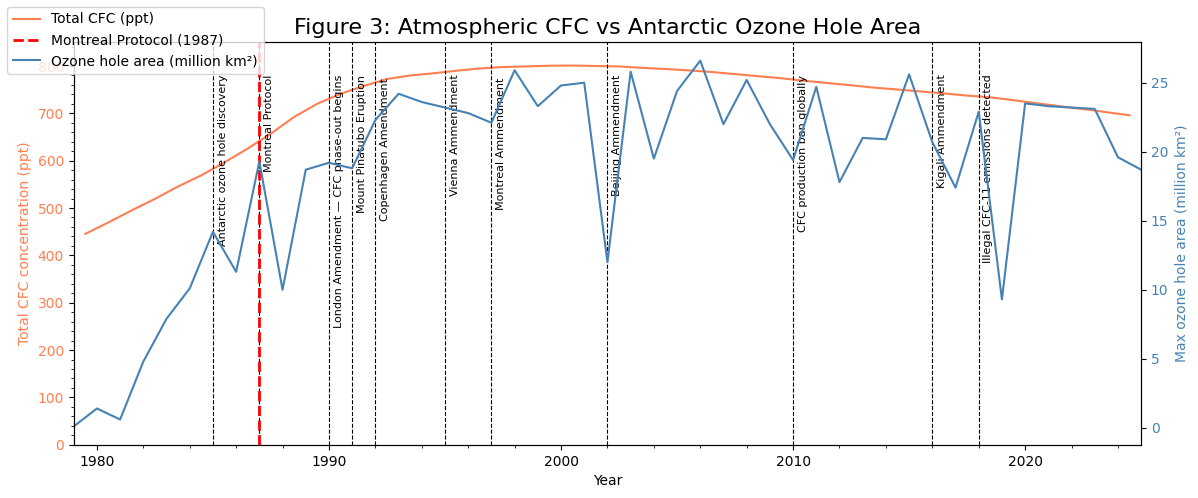

In [13]:
#Plot Combined Total CFC Concentration with Max Ozone Hole Area Data

fig, ax1 = plt.subplots(figsize=(12, 5))

# Left y-axis — CFC total
ax1.plot(year_cfc, cfc_total, color='coral', linewidth=1.5, label='Total CFC (ppt)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total CFC concentration (ppt)', color='coral')
ax1.tick_params(axis='y', labelcolor='coral')
ax1.set_xlim(1979, 2025)
ax1.set_ylim(0, 850)

# Right y-axis — ozone hole area
ax2 = ax1.twinx()
ax2.plot(year_ozone, ozone_area, color='steelblue', linewidth=1.5, label='Ozone hole area (million km²)')
ax2.set_ylabel('Max ozone hole area (million km²)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

# Add policy event lines from the dataframe
for _, row in df_events.iterrows():
    ax1.axvline(x=row['Year'], color='black', linewidth=0.8, linestyle='--')
    ax1.text(x=row['Year'] + 0.2,        # nudge text slightly right of line
            y=ax1.get_ylim()[1] * 0.92,  # place text near top of plot
            s=row['Event'],             # the text label from your Excel sheet
            rotation=90,               # rotate vertically
            fontsize=8,
            color='black',
            va='top')

# Montreal Protocol — thick red line, stands out from other events
ax1.axvline(x=1987, color='red', linewidth=2, linestyle='--', label='Montreal Protocol (1987)')

ax1.set_title('Figure 3: Atmospheric CFC vs Antarctic Ozone Hole Area', fontsize=16)
fig.legend(loc='upper left')
ax1.minorticks_on()
plt.tight_layout()
plt.show()

### Figure 3 interpretation
*   The dual-axis plot confirms that CFC concentration and ozone hole area broadly track each other over the full record: both rise through the 1980s, peak around mid-1990s to mid-2000s, and then decline.
*   After the Montreal Protocol (red line), CFCs peak and turn downward. The ozone hole area continues to rise for about a decade before also turning downward - consistent with the known atmospheric lifetime of CFC-12 (about 100 years), meaning the stratospheric chlorine concentrations remain elevated lonf after surface emissions cease.
*   Visually, the CFC curve appears to lead the ozone hole area by several years, with the CFC peak preceeding the ozone hole peak. This lag is expected because CFCs take time to reach the stratosphere after surface emission, and is investigated in Section 5.

---


# Section 4: Polynomial Detrending (W10_L1_NB2)

The raw ozone hole area record contains both a long-term trend (the signal) and year-to-year variability driven by natural factors such as the polar vortex and volcanic eruptions (the noise).

I have used polynomial detrending to fit a mathemetical record that can approximate the long-term trend regardless of noise.

First, I have plotted different order polynomials against the raw data to figure out which order polynomial to use:

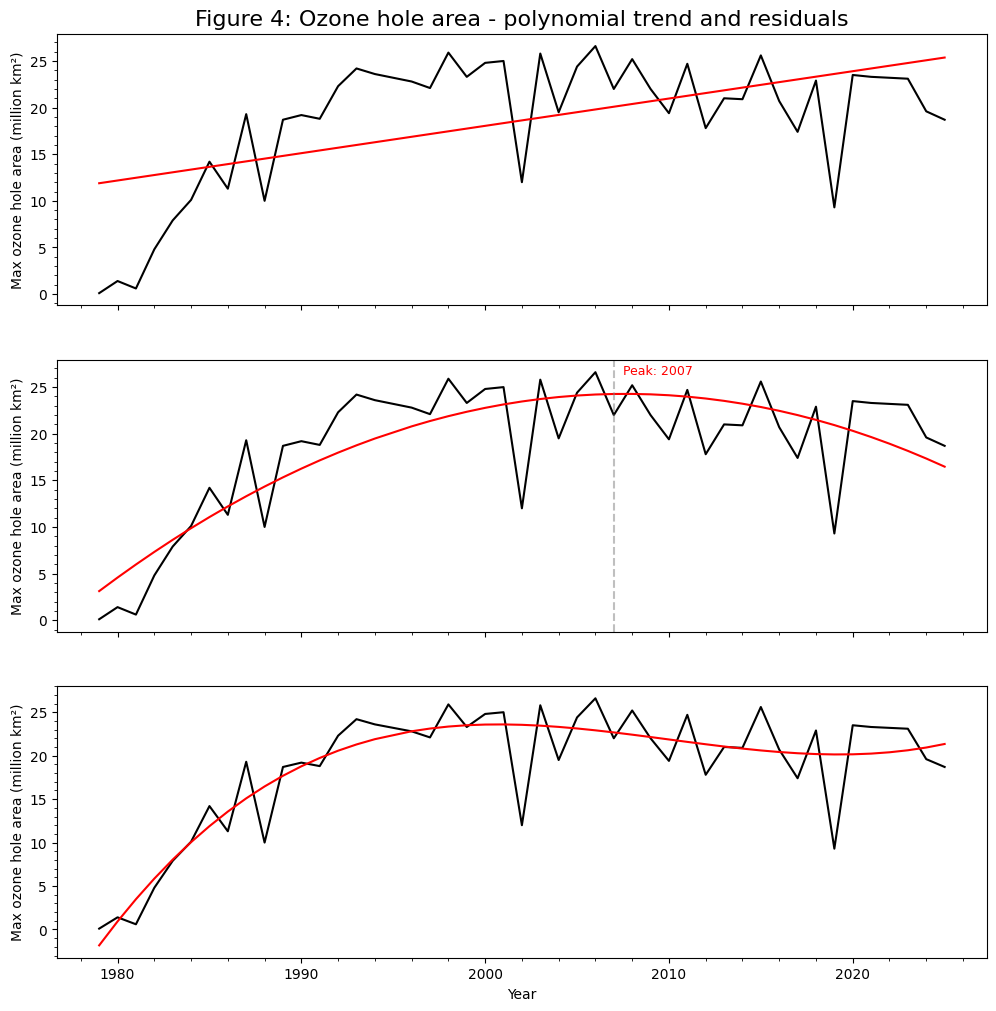

In [14]:
#Fit a linear trend to the full record
pp1 = np.polyfit(year_ozone, ozone_area, 1)
trend1 = np.polyval(pp1, year_ozone)

#Fit a quadratic trend to the full record
pp2 = np.polyfit(year_ozone, ozone_area, 2)
trend2 = np.polyval(pp2, year_ozone)

#calculate peak year and value from the polynomial
peak_year = int(-pp2[1] / (2 * pp2[0])) # vertex formula: -b/2a

#Fit a cubic trend to the full record
pp3 = np.polyfit(year_ozone, ozone_area, 3)
trend3 = np.polyval(pp3, year_ozone)

#Plotting three different-order polynomials into subplots for comparison:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

axes[0].plot(year_ozone, ozone_area, 'k')
axes[0].plot(year_ozone, trend1, 'r')
axes[0].set_ylabel('Max ozone hole area (million km²)')
axes[0].minorticks_on()
axes[0].set_title('Figure 4: Ozone hole area - polynomial trend and residuals', fontsize=16)

axes[1].plot(year_ozone, ozone_area, 'k')
axes[1].plot(year_ozone, trend2, 'r')
axes[1].set_ylabel('Max ozone hole area (million km²)')
axes[1].minorticks_on()
#plotting the peak year onto the quadratic:
axes[1].axvline(x=peak_year, color='gray', linestyle='--', alpha=0.5, label='Peak ozone hole area')
axes[1].text(peak_year + 0.5, 26, f'Peak: {peak_year}', fontsize=9, color='red', va='bottom') # Add a text label

axes[2].plot(year_ozone, ozone_area, 'k')
axes[2].plot(year_ozone, trend3, 'r')
axes[2].set_ylabel('Max ozone hole area (million km²)')
axes[2].set_xlabel('Year')
axes[2].minorticks_on()

Fitting polynomials of orders 1, 2, and 3 against the full record reveals a Goldilocks problem in choosing the correct order:

*   **Order 1** (linear) - gives a weak positive slope, which is misleading -  it averages over the rising and falling phases, and suggests no meaningful change has occurred.  
*   **Order 3** (cubic) - dips below zero before 1979 and curves upward after 2024, neither of which is physically real.
*   **Order 2** (quadratic) - captures the rise, peak, and recovery in a single smooth curve. The polynomial peak year (2007) is also consistent with the observed maximum.

The order two polynomial is therefore selected. The peak of this quadratic - 2007 - was calculated using the vertex of a parabola formula, and is used as the split point between the worsening and recovery phases of the ozone hole. Splitting at 2007 lets us separately quantify the worsening and recovery rates as linear slopes which can then be used for boostrapping and Bayesion regression analysis.

**Assumption:** The order 2 polynomial assumes the recovery is symmetric about the year 2007. If the recovery is accelerating or decelerating non-linearly, this model will not capture that.

Trend slopes from linear regression:
  Pre-2006:  +0.782 million km² per year  (worsening)
  Post-2006: -0.121 million km² per year (recovering)


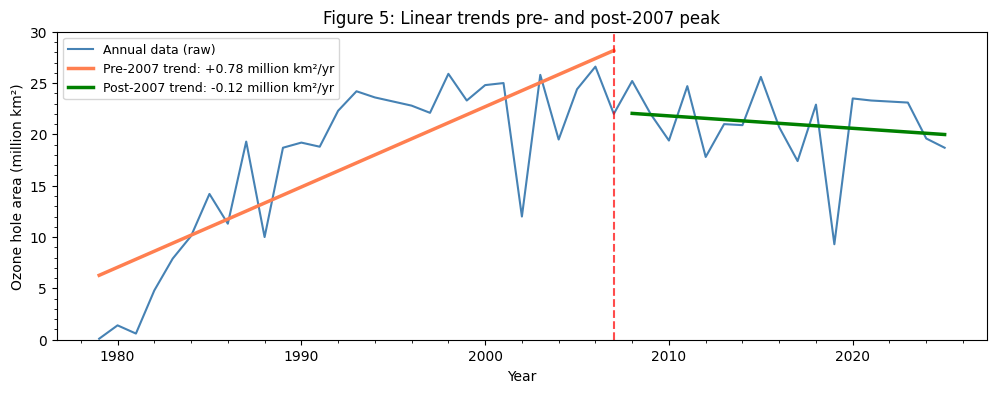

In [15]:
#Split at year 2007, where the ozone hole area peaked
mask_pre  = year_ozone <= peak_year
mask_post = year_ozone > peak_year

year_pre  = year_ozone[mask_pre]
area_pre  = ozone_area[mask_pre]

year_post = year_ozone[mask_post]
area_post = ozone_area[mask_post]

# Linear trends on pre and post 2007 splits
pp_pre  = np.polyfit(year_pre,  area_pre,  1)
pp_post = np.polyfit(year_post, area_post, 1)
trend_pre  = np.polyval(pp_pre,  year_pre)
trend_post = np.polyval(pp_post, year_post)

# plot the split linear trends
fig, ax = plt.subplots(figsize=(12, 4))

plt.plot(year_ozone, ozone_area, color='steelblue', label='Annual data (raw)')
plt.plot(year_pre,  trend_pre, color='coral', linewidth=2.5, label=f'Pre-2007 trend: {pp_pre[0]:+.2f} million km²/yr')
plt.plot(year_post, trend_post, color='green', linewidth=2.5, label=f'Post-2007 trend: {pp_post[0]:+.2f} million km²/yr')
plt.axvline(x=peak_year, color='red', linestyle='--', alpha=0.7) #add a vertical line for 2006 as a visual split

plt.xlabel('Year')
plt.ylabel('Ozone hole area (million km²)')
plt.legend(fontsize=9, loc='upper left')
plt.ylim(0, 30)
plt.title("Figure 5: Linear trends pre- and post-2007 peak")
plt.minorticks_on()

# ── Print slope summary ───────────────────────────────────────────
print("Trend slopes from linear regression:")
print(f"  Pre-2006:  {pp_pre[0]:+.3f} million km² per year  (worsening)")
print(f"  Post-2006: {pp_post[0]:+.3f} million km² per year (recovering)")


### Figure 5 Interpretation

The pre-2007 linear trend shows a clear increase in the ozone hole area of +0.78 million km² per year - a rapid and consistent worsening driven by accumulating stratospheric chlorine from CFC emissions.

The post-2007 linear trend shows a slight decrease of -0.12 million km² per year - a much slower recovery. The recovery rate is approximately 15% of the worsening rate, which reflects the very long atmospheric lifetime of CFCs.

However, these simple linear regression slopes cannot tell us whether the post-2007 recovery is statistically credible or could have arisen by chance due to natural year-to-year variability visible in the data. This is addressed in Section 4 using Bayesian regression.

---


# Section 4: Bayesian Regression Analysis (W8_P1_NB1, W8_P1_NB2)

Simple linear regression gives a single slope value but no information about uncertaintly. For a small, noisy dataset like the post-2007 ozone record (17 years), we need to figure out if the slope is credibly negative, or whether it could plausibly be zero or positive by chance.

Bayesian linear regression (using the bambi package) answers this directly by producing a full posterior probability distribution over all slope values. The 95% Highest Density Interval (HDI) from this posterior tells us the range of slopes consistent with the data at 95% credibility. If this interval excludes zero, the recovery is statistically credible.

Only the post-2007 period is used here as the pre-2007 worsening trend is obvious visually and quantitatively, and most people already know this has happened despite the previous analysis in this notebook.  

First, like the copper mine example in week 8, I have scaled the year values to mean=0 and std=1 for numerical stability:

In [26]:
post_mean = np.mean(year_post)
post_std  = np.std(year_post)

data_post = pd.DataFrame({
    'year_scaled': (year_post - post_mean) / post_std,
    'ozone':        area_post
})

# Fit the bayesian linear model to the post-2006 data:
model_post = bmb.Model("ozone ~ year_scaled", data_post)
idata_post = model_post.fit(
    draws=2000,
    tune=2000,
    chains=4,
    progressbar=False
)

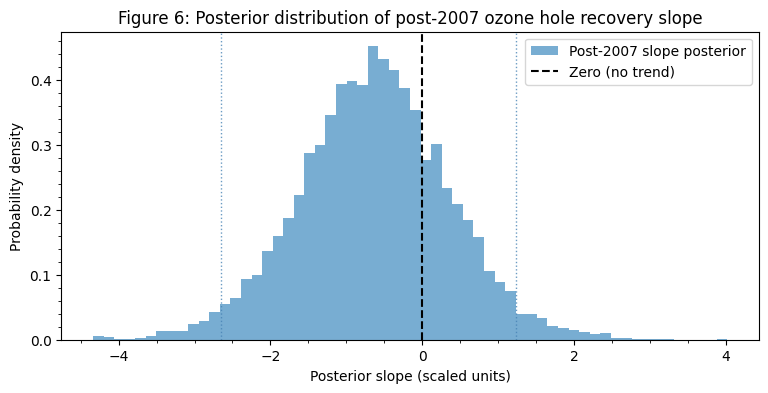

Posterior mean slope:    -0.629 (scaled units)
95% HDI:                 [-2.656, 1.241]


In [17]:
#Plot the posterior distribution of the recovery slope:
slope_post = idata_post.posterior['year_scaled'].values.flatten()

ci_post = az.hdi(slope_post, 0.95)

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(slope_post, bins=60, alpha=0.6, density=True, label='Post-2007 slope posterior')

# Mark zero — if post-2006 HDI excludes zero, recovery is credible
ax.axvline(x=0, color='black', linewidth=1.5,
           linestyle='--', label='Zero (no trend)')

# Mark 95% HDI for post-2006
ax.axvline(x=ci_post[0], color='steelblue', linewidth=1, linestyle=':', alpha=0.8)
ax.axvline(x=ci_post[1], color='steelblue', linewidth=1, linestyle=':', alpha=0.8)

ax.set_xlabel('Posterior slope (scaled units)')
ax.set_ylabel('Probability density')
ax.set_title('Figure 6: Posterior distribution of post-2007 ozone hole recovery slope')
ax.legend()
ax.minorticks_on()
plt.show()

print(f"Posterior mean slope:    {slope_post.mean():.3f} (scaled units)")
print(f"95% HDI:                 [{ci_post[0]:.3f}, {ci_post[1]:.3f}]")

### Figure 6 Interpretation

The posterior distribution represents the full range of recovery rates consistent with the post-2007 data, given our priors and the likelihood of the observations.

The post-2007 ozone record only has 17 data points, and the year-to-year variability is larger relative to its underlying trend. This combination produces a wide posterior.

The posterior mean slope is negative, indicating the model's best estimate is that the ozone hole is shrinking. However, the 95% HDI straddles zero - meaning zero (no recovery) is within the range of possibilities at the 95% credible level.

Therefore, whilst the posterior mean is negative and majority of the probability mass is negative, we cannot rule out the possibility that the apparent recovery is noise, given the limited post-2007 sample size. With each additional year of data, the HDI will narrow and eventually exclude zero.

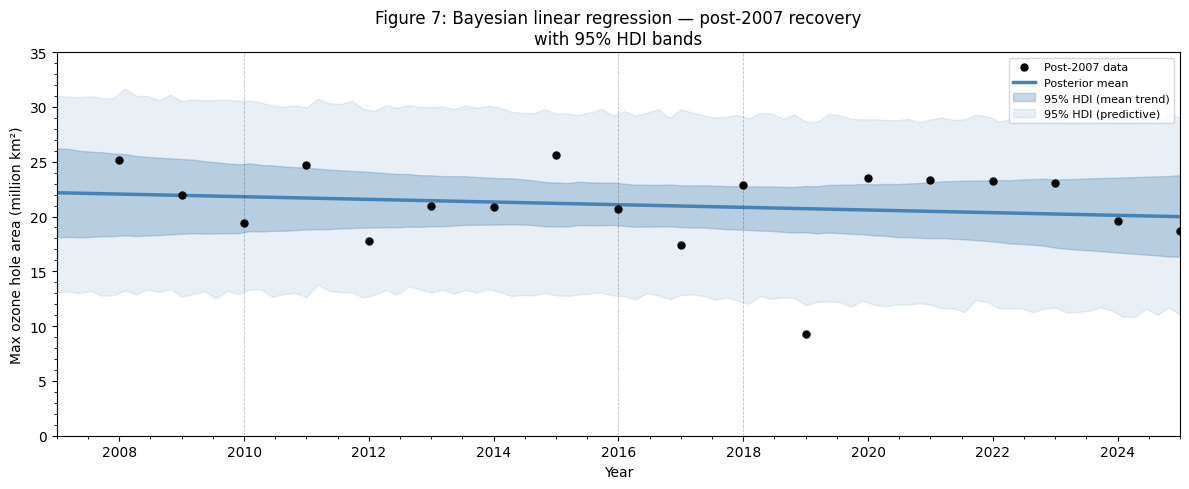

In [23]:
#Plot the regression line with 95% HDI band over data
x_range = np.linspace(peak_year, year_post.max(), 100)
x_range_scaled = (x_range - post_mean) / post_std

new_data = pd.DataFrame({'year_scaled': x_range_scaled})
model_post.predict(idata_post, data=new_data, kind='response_params')
model_post.predict(idata_post, data=new_data, kind='response')

mu_draws  = idata_post.posterior['mu'].values.reshape(-1, 100)
pps_draws = idata_post.posterior_predictive['ozone'].values.reshape(-1, 100)

post_mean_line = mu_draws.mean(axis=0)
hdi_mean = az.hdi(mu_draws.T,  0.95)
hdi_pps = az.hdi(pps_draws.T, 0.95)

#Plot the data
fig, ax = plt.subplots(figsize=(12, 5))

# Post-2006 data highlighted
plt.scatter(year_post, area_post,
           color='black', s=25, zorder=3,
           label='Post-2007 data')

# Posterior mean regression line
plt.plot(x_range, post_mean_line,
        color='steelblue', linewidth=2.5,
        label='Posterior mean')

# 95% HDI on the mean (uncertainty in the trend line)
plt.fill_between(x_range, hdi_mean[:, 0], hdi_mean[:, 1],
                color='steelblue', alpha=0.3,
                label='95% HDI (mean trend)')

# 95% HDI on predictions (uncertainty for a new observation)
plt.fill_between(x_range, hdi_pps[:, 0], hdi_pps[:, 1],
                color='steelblue', alpha=0.12,
                label='95% HDI (predictive)')

for _, row in df_events.iterrows():
    plt.axvline(x=row['Year'], color='black',
               linewidth=0.6, linestyle='--', alpha=0.25)

plt.xlabel('Year')
plt.ylabel('Max ozone hole area (million km²)')
plt.title('Figure 7: Bayesian linear regression — post-2007 recovery\n'
             'with 95% HDI bands')
plt.legend(fontsize=8, loc='upper right')
plt.ylim(0, 35)
plt.xlim(2007,2025)
plt.minorticks_on()
plt.tight_layout()
plt.show()

### Figure 7 Interpretation

The posterior mean regression line shows a gradual decline in ozone hole area over the post-2007 period, consistent with the linear slope in Section 3.

The 95% HDI on the mean trend represents uncertainty in the underlying recovery rate, and the 95% predictive HDI is wider and represents uncertainty in where a new individual observation would fall, incorporating both signal and noise uncertainy.

The 2019 data point is an unusually small outlier, caused by an unusual stratospheric warming event that disrupted the polar vertex and temporarily accelerated apparent recovery beyond what the long-term trend predicts.

**Limitation:** The model assumes a linear trend. If the recovery is non-linear - e.g. accelerates as stratopheric chlorine decreases due to lower production - this model will underestimate the speed of recovery. A larger dataset would allow for testing of non-linear models.

---


# Section 5: Correlation (W8_L1)

The exploratory plots in Section 3 suggest that CFC concentration and ozone hole area track each other, with CFC appearing to lead ozone hole area by several years. Here we formally estimate the correlation coefficient *p* between the two variables using Peason cross-correlation at multiple time lags.

Following the approach from week 8, we first detrend both signals because two increasing variables will appear correlated even if there is no direct relationship, so removing the trend isolates the year-to-year covariation that reflects the relationsip.

We test two versions:
1.   **Lag 0** - CFC and ozone in the same year
2.   **Best lag** - CFC leading ozone by N years (identified below)

A positive lag is expected from a theoretical reasoning: CFCs take several years to reach the stratosphere after being released at the surface.

Sample r at lag 0:       0.810
Best lag:                0 years
Sample r at best lag:    0.810


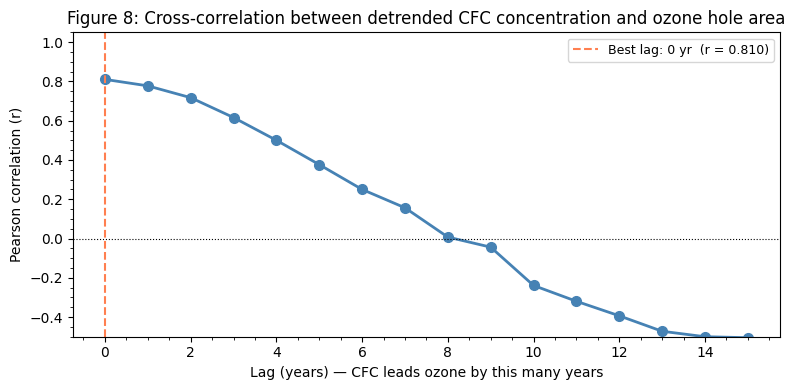

In [24]:
from scipy.signal import detrend

# Detrend both signals to remove the shared long-term trend
# before computing correlation — prevents spurious high correlation
cfc_anom   = detrend(cfc_total)
ozone_anom = detrend(ozone_area)

# Note: after detrending, arrays must be same length
# Trim CFC to match ozone length if needed
min_len    = min(len(cfc_anom), len(ozone_anom))
cfc_anom   = cfc_anom[:min_len]
ozone_anom = ozone_anom[:min_len]

max_lag     = 15
lags        = np.arange(0, max_lag + 1)
corr_coeffs = np.zeros(len(lags))

for i, lag in enumerate(lags):
    if lag == 0:
        corr_coeffs[i] = np.corrcoef(cfc_anom, ozone_anom)[0, 1]
    else:
        # Shift: CFC at time t vs ozone at time t+lag
        corr_coeffs[i] = np.corrcoef(
            cfc_anom[:-lag],
            ozone_anom[lag:]
        )[0, 1]

best_lag  = lags[np.argmax(corr_coeffs)]
best_corr = corr_coeffs[np.argmax(corr_coeffs)]

print(f"Sample r at lag 0:       {corr_coeffs[0]:.3f}")
print(f"Best lag:                {best_lag} years")
print(f"Sample r at best lag:    {best_corr:.3f}")

# Plot cross-correlation
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lags, corr_coeffs, 'o-', color='steelblue',
        linewidth=2, markersize=7)
ax.axvline(x=best_lag, color='coral', linewidth=1.5,
           linestyle='--',
           label=f'Best lag: {best_lag} yr  (r = {best_corr:.3f})')
ax.axhline(y=0, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('Lag (years) — CFC leads ozone by this many years')
ax.set_ylabel('Pearson correlation (r)')
ax.set_title('Figure 8: Cross-correlation between detrended CFC '
             'concentration and ozone hole area')
ax.legend(fontsize=9)
ax.set_ylim(-0.5, 1.05)
ax.minorticks_on()
plt.tight_layout()
plt.show()

### Cross-correlation Model Interpretation

The cross-correlationplot shows a strong positive correlation of r=0.81 at lag 0, since this is the best lag, any lag higher will have a progressively less strong correlation.

This strong correlation confirms that higher CFC concentrations are linked with large ozone hole area, consistent with the known physical mechanism.


**Limitation - why lag 0?**

A best lag of 0 means that the two time series are most similar when compared at the same time step. However, this is not what we expected from the data.

This is likely due to the CFC dataset consisting of smoothed global annual mean concetrations across multiple monitoring stations. The CFC curve is so smooth that shifting it a few years changes its shape very little, removing the year-to-year variability that would allow the cross-correlation algorithms to detect a time delay.

In reality, CFCs take approximately 5–10 years to reach the stratosphere where ozone-depletion occurs. A higher-resolution monthly dataset is needed to calculate the actual correct positive lag. This is a limitation of the dataset rather than a flaw in this method.

---


# Section 6: Forward Projection (W8_P1_NB1, W7_L1_NB2)



Having established a posterior distribution for the post-2007 recovery rate, we can use the Bayesian model to project ozone hole area forward in time and compute the probability of reaching a defined recovery threshold by 2070.

This combines two classwork approaches:
*   The **posterior predictive distribution from W8_P1_NB1**, which generates probabilistic forecasts for future observations incorporating trend and natural uncertainty.
*   The **threshold probability method from W7_L1_NB2**, which computes P(variable < threshold) by counting the fraction of posterior samples that fall below the threshold at each future time point.

I defined the recovery threshold to be 10 million km² - the maximum ozone hole area observed in the early 1980s before the ozone hole was discovered and significant ozone depletion occurred. This threshold hence represents a return to near per-depletion conditions.

**Assumptions:**
*   This projection extrapolates the post-2007 linear trend to the future, assuming the recovery rate remains constant.
*   The measured ozone hole area prior to significant depletion is the natural ozone state. There is a lack of observed evidence to support this, for all we know the ozone hole may not have existed at all or could be very variable and have a wide range of 'natural' states.

In [20]:
#Note: AI was used to assist with the following code

recovery_threshold = 10.0  # million km²
future_years       = np.arange(year_post.max() + 1, 2071)
future_scaled      = (future_years - post_mean) / post_std

new_data_future = pd.DataFrame({'year_scaled': future_scaled})

# Get posterior predictive samples at each future year
model_post.predict(idata_post, data=new_data_future, kind='response_params')
model_post.predict(idata_post, data=new_data_future, kind='response')

mu_future  = idata_post.posterior['mu'].values.reshape(-1, len(future_years))
pps_future = idata_post.posterior_predictive['ozone'].values.reshape(-1, len(future_years))

future_mean_line = mu_future.mean(axis=0)
future_hdi_mean  = az.hdi(mu_future.T,  0.95)
future_hdi_pps   = az.hdi(pps_future.T, 0.95)

# Probability of being below threshold at each future year
prob_recovered = np.mean(pps_future < recovery_threshold, axis=0)

# Year when probability first exceeds 50%
if np.any(prob_recovered >= 0.5):
    yr_50 = future_years[np.argmax(prob_recovered >= 0.5)]
    print(f"P(recovered) first exceeds 50% in: {yr_50}")
else:
    yr_50 = None
    print("Recovery below threshold not projected before 2070.")

if np.any(prob_recovered >= 0.95):
    yr_95 = future_years[np.argmax(prob_recovered >= 0.95)]
    print(f"P(recovered) first exceeds 95% in: {yr_95}")
else:
    yr_95 = None
    print("95% recovery probability not projected before 2070.")

Recovery below threshold not projected before 2070.
95% recovery probability not projected before 2070.


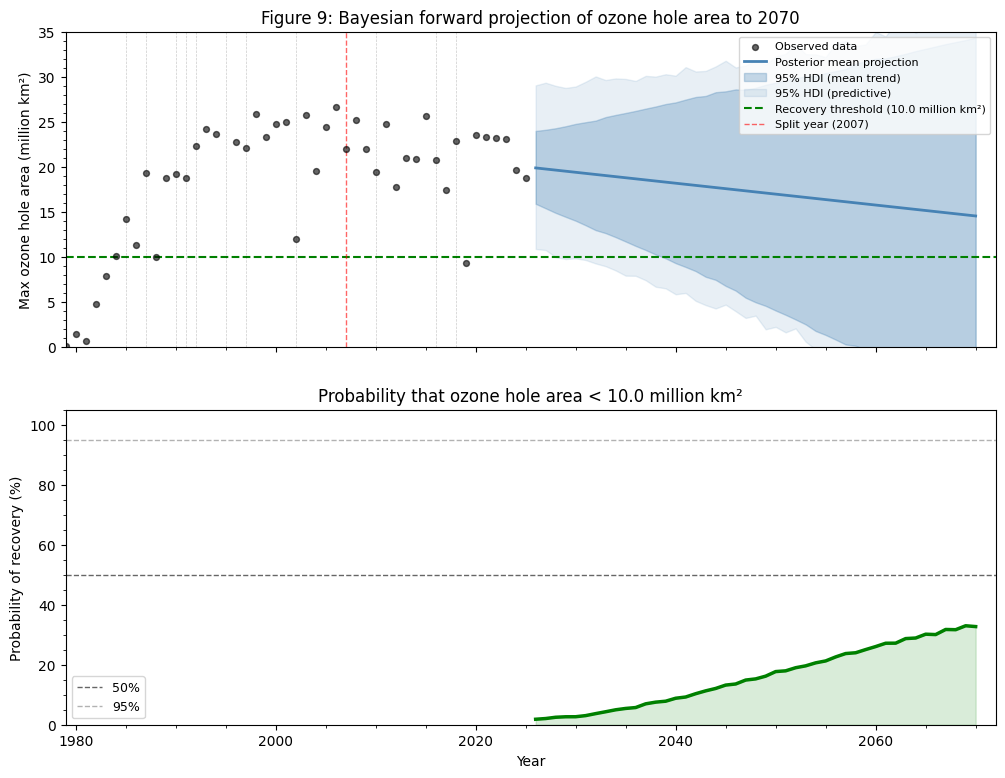

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# ── Panel 1: Projection ───────────────────────────────────────────
axes[0].scatter(year_ozone, ozone_area,
                color='black', s=18, alpha=0.6,
                zorder=3, label='Observed data')
axes[0].plot(future_years, future_mean_line,
             color='steelblue', linewidth=2,
             label='Posterior mean projection')
axes[0].fill_between(future_years,
                     future_hdi_mean[:, 0], future_hdi_mean[:, 1],
                     color='steelblue', alpha=0.3,
                     label='95% HDI (mean trend)')
axes[0].fill_between(future_years,
                     future_hdi_pps[:, 0], future_hdi_pps[:, 1],
                     color='steelblue', alpha=0.12,
                     label='95% HDI (predictive)')
axes[0].axhline(y=recovery_threshold, color='green',
                linewidth=1.5, linestyle='--',
                label=f'Recovery threshold ({recovery_threshold} million km²)')
axes[0].axvline(x=peak_year, color='red', linewidth=1,  # fixed: peak_year not split_year
                linestyle='--', alpha=0.6,
                label=f'Split year ({peak_year})')

if yr_50:
    axes[0].axvline(x=yr_50, color='green', linewidth=1,
                    linestyle=':', alpha=0.8)
    axes[0].text(yr_50 + 0.5, 1,
                 f'50% recovery\nby {yr_50}',
                 fontsize=8, color='green', va='bottom')

for _, row in df_events.iterrows():
    axes[0].axvline(x=row['Year'],          # fixed: capital Y
                    color='black', linewidth=0.5,
                    linestyle='--', alpha=0.2)

axes[0].set_ylabel('Max ozone hole area (million km²)')
axes[0].set_title('Figure 9: Bayesian forward projection of ozone hole area to 2070')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_ylim(0, 35)
axes[0].set_xlim(1979, 2072)  # focus on post-peak period only
axes[0].minorticks_on()

# ── Panel 2: Probability of recovery ─────────────────────────────
axes[1].plot(future_years, prob_recovered * 100,
             color='green', linewidth=2.5)
axes[1].fill_between(future_years, 0, prob_recovered * 100,
                     color='green', alpha=0.15)
axes[1].axhline(y=50, color='black', linewidth=1,
                linestyle='--', alpha=0.6, label='50%')
axes[1].axhline(y=95, color='gray', linewidth=1,
                linestyle='--', alpha=0.6, label='95%')

if yr_50:
    axes[1].axvline(x=yr_50, color='green', linewidth=1.5,
                    linestyle=':', label=f'50% by {yr_50}')
if yr_95:
    axes[1].axvline(x=yr_95, color='gray', linewidth=1.5,
                    linestyle=':', label=f'95% by {yr_95}')

axes[1].set_xlabel('Year')
axes[1].set_ylabel('Probability of recovery (%)')
axes[1].set_title(f'Probability that ozone hole area < {recovery_threshold} million km²')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 105)
axes[1].minorticks_on()

plt.show()

### Figure 9 Interpretation

**Panel 1 - Projection**

The posterior mean projection shows the ozone hole area continuing to decline slowly after 2025, reaching approximately 14-15 million km² by 2070 under the mean trend. The wide 95% predictive HDI band honestly two sources of uncertainty:
1.   **Trend uncertainty:** The posterior slope distribution (Figure 7) is wide as only 17 data points are available post-2007. This uncertainty grows linearly as the projection extends further into the future.
2.   **Natural variability:** The predictive HDI includes year-to-year variability driven by the polar vortex (±5 million km²), which does not shrink with more data as it is an observed phenomenon rather than estimation uncertainty.

The green dashed recovery threshold line is not reached by the posterior mean projection before 2070, though it fall within the lower edge of the predictive HDI, meaning it is plausible but not likely.

**Panel 2 - Recovery probability**

The probability of the ozone hole falling below 10 million km² grows slowly, reaching approximately 33% by 2070. This doesn't mean recovery won't occur, only that we cannot confidently predict recovery before 2070.

This result is a projection based on linear extrapolation from a short, noisy record. It is therefore not a prediction that the ozone will not recover.

### Limitations:
*   **Small post-2007 sample (n=17):** The wide HDI bands are a result of such a small sample size. Each additional year of data will narrow the posterior and hence improve prediction reliability.
*   **Linear trend assumption:** The model assumes recovery proceeds at a constant rate, whereas in reality, as stratopheric chlorine levels fall, the rate of ozone recovery should increase.
*   **Ozone hole assumed at baseline:** The recovery threshold is an approximation due to the lack of knowledge about what the natural ozone state would actually be prior to this event.
*   **Illegal CFC-11 emissions (2018-2019):** The detection of illegal CFC emissions temporarily slowed the CFC-11 decline and hence the ozone recovery. Therefore, the ozone recovery rate may be underestimated and it might recover faster than predicted.
*   **Natural variability (e.g. volcanic outgassing):** The Pinatubo eruption in 1991 temporarily accelerated ozone depletion by about 2-3 years. Any major future eruption could hence have the same effect on the recovery rate, which cannot be modelled as eruptions and climate events cannot accurately be predicted long-term.  

---
# Discussion

### Summary
This project investigated whether the recovery of the Antarctic ozone hole following CFC regulation is statistically detectable in real atmospheric measurements.

**Fermi estimation** established that the total CFC-12 ever produced could theoretically destroy the ozone layer approximately 397 times over. This motivated why the recovery is a slow and uncertain process.

**Exploratory analysis** confirmed that CFC-11 and CFC-12 concentrations peaked in the mid-1990s and have declined following the Montreal Protocol, while the ozone area peaked in 2007 - approximately 10-15 years after the CFC peak, consistent with the expected atmospheric transport lag and long lifetime of CFC-12.

**Polynomial detrending and trend splitting** quantified the worsening rate as +0.78 million km²/yr and recovery rate as -0.12 million km²/yr (post-2007). The recovery rate is about 15% of the worsening rate, consistent with the known persistance of stratospheric chlorine from CFCs.

**Bayesian regression** produced a posterior distribution for the recovery slope with a negative mean but a 95% HDI straddling zero. This means the recovery is consistent with the data but cannot yet be confirmed as statistically credible.

**Correlation analysis** found a strong positive correlation between CFC concentration in the atmosphere and ozone hole area over time. The expected 5-10 year lag could not be resolved due to the smoothness of the CFC dataset.

**Forward projection** found that recovery below 10 million km² is not projected with 50% probability before 2070 under the current trend, reflecting the shallow post-2007 recovery slope and large natural variability in the ozone layer.

### Answering the research question
*Can we detect the signature of CFC regulation in real atmospheric measurements, and quantify the statistical certainty of the observed ozone hole recovery?*

Yes, partially. The decline in CFC regulation is clearly visible in the atmospheric record as well as the corresponding decline in ozone hole area. However, the Bayesian analysis shows that this recovery trend cannot yet be confirmed as statistically credible at the 95% level. The fundamental constraint is sample size as 17 years of noisy post-2007 data is insufficient to narrow the posterior slope distribution enough to exclude zero.

The hypothesis is supported in direction but cannot yet be confirmed with high statistical confidence.

Overall, the Montreal Protocol is one of the most successful international environmental interventions in history. This analysis provides visual and quantitative evidence that the atmospheric response is detectable, even if full statistical confirmation of recovery is yet to be observed.



---


# Individual Reflection

I chose the ozone hole recovery as my project as it is such a clear example of a human policy intervention that had a huge environmental effect. It is also one of the most famous examples too so I thought that would make it more eyecatching and engaging to present. I was motivated by wanting to quantify a recovery, and also the uncertainty, because no one I know seems to know the answer to this.

The most significant challenge I faced was finding a CFC dataset. I searched through quite a lot to find the one I did and even then, it is not of the quality that I wanted. I had originally planned to do cross-correlation between the CFC concentration and ozone hole area and have this as one of my strongest talking points, however when I began I realised that I was unable to calculate the lag as the dataset was too smooth, lacking the variability needed for lag detection. I discovered this through the analysis in the code, I tried multiple different methods and played around with the code but no matter what, it always returned a best lag of 0. I hence did a little research as to why this was happening and was slightly relieved but also frustrated to discover it wasn't my code that was the issue, but the dataset itself. In hindsight, I would choose a dataset with monthly station-level CFC data and average it myself where needed.

Initially, I had a moving averages sections which did display a good knowledge of the skill we used in class, however I felt it did not add anything, especially as I already had the polynomial detrending. Having two different trend analysis techniques was uneccessary and hence I removed that section and strengthened the polynomial section.

The key strength of the analysis is the flow from end to end with justification and description for each section. From the Fermi estimation to motivate and set up the question, to trend characterisation, to a probabilistic projection with explicitly stated uncertainty. The key shortcoming is the reliance on overly smoothed CFC data (discussed above), as well as the linear projection assumption. Using first order polynomials to predict the recovery trend is more unrealistic as the recovery rate is likely to increase as the amount of Cl in the stratosphere decreases. However, as we don't know what is going to happen I figured it was better to simplify the forecasting rather than overcomplicate and forecast the trend wrong.

Overall, I am happy with the quality of my notebook, and also struggled a lot more than initially expected with organisation, finding datasets, writing code that gave me the correct output, and also providing good quality visualisation.
